# Example 1: Steady-State Operating Points of a CSTR with a Consecutive Reaction

This example is adapted from Robert Güttel, Lecture Notes Chemical Reaction Engineering III, Ulm University, 2022.

This notebook implements the numerical solution of the dimensionless material and energy balances derived in Example 1 for a cooled continuous stirred-tank reactor (CSTR) with the consecutive reaction network

$$R_1:\quad A_1 \xrightarrow{k_1} A_2,\qquad R_2:\quad A_2 \xrightarrow{k_2} A_3.$$

Both reactions are first-order in the respective reactant and follow Arrhenius kinetics. The reference quantities are $c_\mathrm{ref}=c_{1,\mathrm{in}}$, $T_\mathrm{ref}=T_\mathrm{in}$, $\tau=V_\mathrm{react}/\dot V$ and $r_\mathrm{ref}=k_1(T_\mathrm{ref})\,c_\mathrm{ref}$, so that $\vartheta_\mathrm{in}=1$.

**Goals**
1. Solve the coupled non-linear system (eqs. 5a–5d) for the steady-state operating points $(f_1, f_2, f_3, \vartheta)$.
2. Evaluate the heat-removal line and heat-formation curve (eq. 6) and visualise the solution in a van-Heerden diagram.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

## Parameters

All parameters are collected in a single dictionary `params`, so later variations require changing only one cell. The default set mirrors the parameter values stated in `6_Example_1.tex` for Example 1.

With the corrected Arrhenius scaling, `k0_ratio` is the pre-exponential-factor ratio $k_{0,2}/k_{0,1}$. The current value $k_{0,2}/k_{0,1}=100$ yields the five steady-state operating points shown in the van-Heerden diagram.

| Quantity | Symbol | Default |
| --- | --- | --- |
| Damköhler number | $\mathrm{Da}_\mathrm{I}$ | $1.0$ |
| Arrhenius number $R_1$ | $\gamma_1$ | $35$ |
| Arrhenius number $R_2$ | $\gamma_2$ | $50$ |
| Prater number $R_1$ | $\beta_1$ | $0.6$ |
| Prater number $R_2$ | $\beta_2$ | $0.9$ |
| Wall Stanton number | $\mathrm{St}_w$ | $2.0$ |
| Cooling temperature | $\vartheta_\mathrm{cool}$ | $0.85$ |
| Inlet fractions | $\kappa_1,\kappa_2,\kappa_3$ | $1,\,0,\,0$ |
| Frequency factor ratio | $k_{0,2}/k_{0,1}$ | $100$ |

In [2]:
params = {
    "Da":         1.0,     # Damkoehler number Da_I
    "gamma_1":   35.0,     # Arrhenius number, reaction 1
    "gamma_2":   50.0,     # Arrhenius number, reaction 2
    "beta_1":     0.6,    # Prater number, reaction 1
    "beta_2":     0.9,    # Prater number, reaction 2
    "St_w":       2.0,     # wall Stanton number
    "theta_cool": 0.85,    # dimensionless cooling temperature
    "kappa":      np.array([1.0, 0.0, 0.0]),  # dimensionless inlet fractions
    "k0_ratio":   100.0,   # frequency factor ratio k0_2 / k0_1
}


## Dimensionless kinetics

With the Arrhenius number $\gamma_j = E_{A,j}/(R\,T_\mathrm{ref})$, the dimensionless reaction rates read (see `6_Example_1.tex`):

$$\frac{r_1}{r_\mathrm{ref}} = \exp\!\left(\gamma_1-\frac{\gamma_1}{\vartheta}\right)\,f_1,$$

$$\frac{r_2}{r_\mathrm{ref}} = \frac{k_{0,2}}{k_{0,1}}\,\exp\!\left(\gamma_1-\frac{\gamma_2}{\vartheta}\right)\,f_2.$$

In [3]:
def rate_factor_1(theta, p):
    """Dimensionless kinetic factor k_1(T) / k_1(T_ref)."""
    return np.exp(p["gamma_1"] - p["gamma_1"] / theta)


def rate_factor_2(theta, p):
    """Dimensionless kinetic factor k_2(T) / k_1(T_ref)."""
    return p["k0_ratio"] * np.exp(p["gamma_1"] - p["gamma_2"] / theta)


def omega_1(theta, f1, p):
    """Dimensionless rate of reaction 1 (r_1 / r_ref)."""
    return rate_factor_1(theta, p) * f1


def omega_2(theta, f2, p):
    """Dimensionless rate of reaction 2 (r_2 / r_ref)."""
    return rate_factor_2(theta, p) * f2


## Material balances (eqs. 5a–5c)

$$A_1:\quad 0 = \kappa_1 - f_1 - \mathrm{Da}_\mathrm{I}\,\frac{r_1}{r_\mathrm{ref}}$$

$$A_2:\quad 0 = \kappa_2 - f_2 + \mathrm{Da}_\mathrm{I}\left(\frac{r_1}{r_\mathrm{ref}} - \frac{r_2}{r_\mathrm{ref}}\right)$$

$$A_3:\quad 0 = \kappa_3 - f_3 + \mathrm{Da}_\mathrm{I}\,\frac{r_2}{r_\mathrm{ref}}$$

In [4]:
def mass_balances(f, theta, p):
    """Residuals of the three component mass balances (eqs. 5a-5c)."""
    w1 = omega_1(theta, f[0], p)
    w2 = omega_2(theta, f[1], p)
    kappa = p["kappa"]
    Da = p["Da"]
    return np.array([
        kappa[0] - f[0] - Da * w1,
        kappa[1] - f[1] + Da * (w1 - w2),
        kappa[2] - f[2] + Da * w2,
    ])

## Energy balance (eq. 5d)

$$T:\quad 0 = 1 - \vartheta + \mathrm{St}_w\,(\vartheta_\mathrm{cool} - \vartheta) + \mathrm{Da}_\mathrm{I}\!\left(\beta_1\,\frac{r_1}{r_\mathrm{ref}} + \beta_2\,\frac{r_2}{r_\mathrm{ref}}\right)$$

In [5]:
def energy_balance(f, theta, p):
    """Residual of the dimensionless energy balance (eq. 5d)."""
    w1 = omega_1(theta, f[0], p)
    w2 = omega_2(theta, f[1], p)
    return (1.0 - theta
            + p["St_w"] * (p["theta_cool"] - theta)
            + p["Da"] * (p["beta_1"] * w1 + p["beta_2"] * w2))

## Coupled residual system and steady-state operating points

The full 4-dimensional residual vector is assembled from eqs. 50a–50d with unknown vector $x = (f_1, f_2, f_3, \vartheta)$. Each steady-state operating point is a root of this system.

To capture all roots, we start `scipy.optimize.fsolve` from a grid of temperature guesses over $\vartheta \in [0.8, 1.5]$. For each guess we first solve the mass balances at the frozen temperature in closed form to obtain a physically consistent composition guess; the resulting $(f_1, f_2, f_3, \vartheta_0)$ is then used as the starting point for the coupled system. Duplicate roots are filtered by the distance in $\vartheta$.

In [6]:
def cstr_residuals(x, p):
    """Full residual vector for eqs. 50a-50d (order: f1, f2, f3, theta)."""
    f = x[:3]
    theta = x[3]
    res = np.empty(4)
    res[:3] = mass_balances(f, theta, p)
    res[3] = energy_balance(f, theta, p)
    return res


def composition_at(theta, p):
    """Solve the three mass balances at a fixed theta for (f1, f2, f3).

    For the consecutive first-order network with kappa = (kappa_1, kappa_2, kappa_3)
    the mass balances are linear in f and can be solved in closed form."""
    r1 = p["Da"] * rate_factor_1(theta, p)
    r2 = p["Da"] * rate_factor_2(theta, p)
    k = p["kappa"]
    f1 = k[0] / (1.0 + r1)
    f2 = (k[1] + r1 * f1) / (1.0 + r2)
    f3 = k[2] + r2 * f2
    return np.array([f1, f2, f3])


def find_steady_states(p, theta_grid=None, tol=1e-4):
    """Scan over theta_grid, start fsolve from each guess, return unique roots."""
    if theta_grid is None:
        theta_grid = np.linspace(0.8, 1.5, 160)
    solutions = []
    for theta0 in theta_grid:
        f0 = composition_at(theta0, p)
        if np.any(np.isnan(f0)):
            continue
        x0 = np.concatenate([f0, [theta0]])
        x_sol, _, ier, _ = fsolve(cstr_residuals, x0, args=(p,),
                                  full_output=True, xtol=1e-12)
        if ier != 1:
            continue
        if x_sol[3] <= 0:
            continue
        if np.max(np.abs(cstr_residuals(x_sol, p))) > 1e-8:
            continue
        solutions.append(x_sol)
    if not solutions:
        return np.empty((0, 4))
    solutions = np.array(solutions)
    solutions = solutions[np.argsort(solutions[:, 3])]
    unique = [solutions[0]]
    for s in solutions[1:]:
        if abs(s[3] - unique[-1][3]) > tol:
            unique.append(s)
    return np.array(unique)


ss = find_steady_states(params)
print(f"Number of steady-state operating points: {len(ss)}\n")
print(f"{'No.':>3} {'theta':>8} {'f1':>10} {'f2':>10} {'f3':>10} {'sum(f)':>10}")
for i, x in enumerate(ss, 1):
    print(f"{i:>3} {x[3]:>8.4f} {x[0]:>10.4f} {x[1]:>10.4f} {x[2]:>10.4f} {x[:3].sum():>10.4f}")

Number of steady-state operating points: 5

No.    theta         f1         f2         f3     sum(f)
  1   0.9049     0.9753     0.0247     0.0000     1.0000
  2   1.0000     0.5001     0.4999     0.0000     1.0000
  3   1.0900     0.0526     0.9456     0.0018     1.0000
  4   1.2721     0.0006     0.4255     0.5740     1.0000
  5   1.3928     0.0001     0.0240     0.9760     1.0000


## Heat removal line and heat formation curve

Rearranging the energy balance yields the graphical form used in `6_Example_1.tex`:

$$\underbrace{\vartheta - 1 + \mathrm{St}_w\,(\vartheta - \vartheta_\mathrm{cool})}_{\dot Q'_\mathrm{rem}(\vartheta)} \;=\; \underbrace{\mathrm{Da}_\mathrm{I}\!\left(\beta_1\,\tfrac{r_1}{r_\mathrm{ref}} + \beta_2\,\tfrac{r_2}{r_\mathrm{ref}}\right)}_{\dot Q'_\mathrm{R}(\vartheta)}$$

The left-hand side is a straight line with slope $1 + \mathrm{St}_w$ (heat-removal line). The right-hand side is a non-linear function of $\vartheta$ (heat-formation curve). To evaluate $\dot Q'_\mathrm{R}(\vartheta)$ we first solve the three mass balances for $(f_1, f_2, f_3)$ at each $\vartheta$ via `composition_at`, so that the curve represents the reaction heat compatible with the material balances. Intersections of both curves are the steady-state operating points.

In [7]:
def Q_removal(theta, p):
    """Heat-removal line (linear in theta)."""
    return (theta - 1.0) + p["St_w"] * (theta - p["theta_cool"])


def Q_generation(theta, p):
    """Heat-formation curve, composition eliminated via the mass balances."""
    theta = np.atleast_1d(theta).astype(float)
    r1 = p["Da"] * rate_factor_1(theta, p)
    r2 = p["Da"] * rate_factor_2(theta, p)
    k = p["kappa"]
    f1 = k[0] / (1.0 + r1)
    f2 = (k[1] + r1 * f1) / (1.0 + r2)
    return p["beta_1"] * r1 * f1 + p["beta_2"] * r2 * f2


theta_range = np.linspace(0.85, 1.5, 601)
Q_rem = Q_removal(theta_range, params)
Q_gen = Q_generation(theta_range, params)

## Van-Heerden diagram

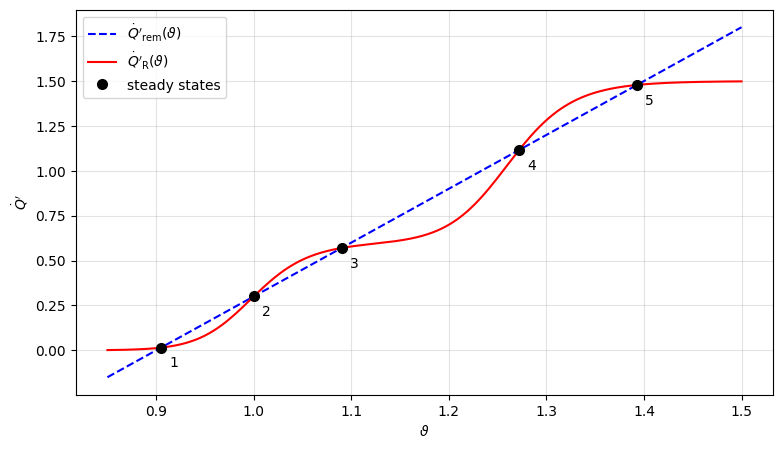

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(theta_range, Q_rem, 'b--', label=r"$\dot Q'_\mathrm{rem}(\vartheta)$")
ax.plot(theta_range, Q_gen, 'r-',  label=r"$\dot Q'_\mathrm{R}(\vartheta)$")

if len(ss) > 0:
    Q_ss = Q_removal(ss[:, 3], params)
    ax.plot(ss[:, 3], Q_ss, 'ko', markersize=7, label="steady states")
    for i, x in enumerate(ss, 1):
        ax.annotate(str(i), (x[3], Q_removal(x[3], params)),
                    xytext=(6, -14), textcoords="offset points")

ax.set_xlabel(r"$\vartheta$")
ax.set_ylabel(r"$\dot Q'$")
ax.grid(alpha=0.35)
ax.legend(loc="upper left")
plt.show()

## Verification

Quick check of the mass closure $\sum_i f_i = \sum_i \kappa_i$ and of the residual magnitude at each operating point.

In [9]:
kappa_sum = params["kappa"].sum()
print(f"{'No.':>3} {'theta':>8} {'sum(f) - sum(kappa)':>22} {'max |residual|':>18}")
for i, x in enumerate(ss, 1):
    mass_err = x[:3].sum() - kappa_sum
    res_norm = np.max(np.abs(cstr_residuals(x, params)))
    print(f"{i:>3} {x[3]:>8.4f} {mass_err:>22.2e} {res_norm:>18.2e}")

No.    theta    sum(f) - sum(kappa)     max |residual|
  1   0.9049               0.00e+00           4.34e-17
  2   1.0000              -1.11e-16           6.66e-16
  3   1.0900               0.00e+00           4.67e-14
  4   1.2721              -1.11e-16           8.88e-16
  5   1.3928               0.00e+00           6.60e-15
